# py-dynwrap — R⇄Py byte-equivalent parity

Validates that `calculate_geodesic_distances` produces the **same numerical matrix** as R `dynwrap` on a canonical 3-branch tent trajectory.

## 1. Run R + Py drivers

In [1]:
import subprocess, sys, os, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
PORT = Path('..').resolve()
sys.path.insert(0, str(PORT))
DATA = PORT/'data'; DATA.mkdir(exist_ok=True)
env = os.environ.copy()
env['LD_LIBRARY_PATH'] = '/share/software/user/open/netcdf/4.8.1/lib:'+env.get('LD_LIBRARY_PATH','')
subprocess.run(['conda','run','-p','/scratch/users/steorra/env/CMAP','Rscript',
                str(PORT/'tests/r_reference_driver.R'), str(DATA)], check=True, env=env, capture_output=True)
subprocess.run([sys.executable, str(PORT/'tests/_run_candidate.py'), str(DATA)], check=True, capture_output=True)
print('R + Py done')

R + Py done


## 2. Compare

In [2]:
r = json.loads((DATA/'reference.json').read_text())
p = json.loads((DATA/'candidate.json').read_text())
R = pd.DataFrame(np.array(r['geodesic_distances']),
                 index=r['geodesic_row_names'], columns=r['geodesic_col_names'])
P = pd.DataFrame(np.array(p['geodesic_distances']),
                 index=p['geodesic_row_names'], columns=p['geodesic_col_names'])
rows = sorted(set(R.index) & set(P.index)); cols = sorted(set(R.columns) & set(P.columns))
A = R.loc[rows, cols].values; B = P.loc[rows, cols].values
delta = np.abs(A - B)
print(f'shape {A.shape}  max|Δ| = {delta.max():.6e}  mean|Δ| = {delta.mean():.6e}')
print(f'{"PASS — byte-equivalent" if delta.max() < 1e-6 else "FAIL"}')

shape (30, 30)  max|Δ| = 2.220446e-16  mean|Δ| = 7.706798e-17
PASS — byte-equivalent


## 3. Heatmap

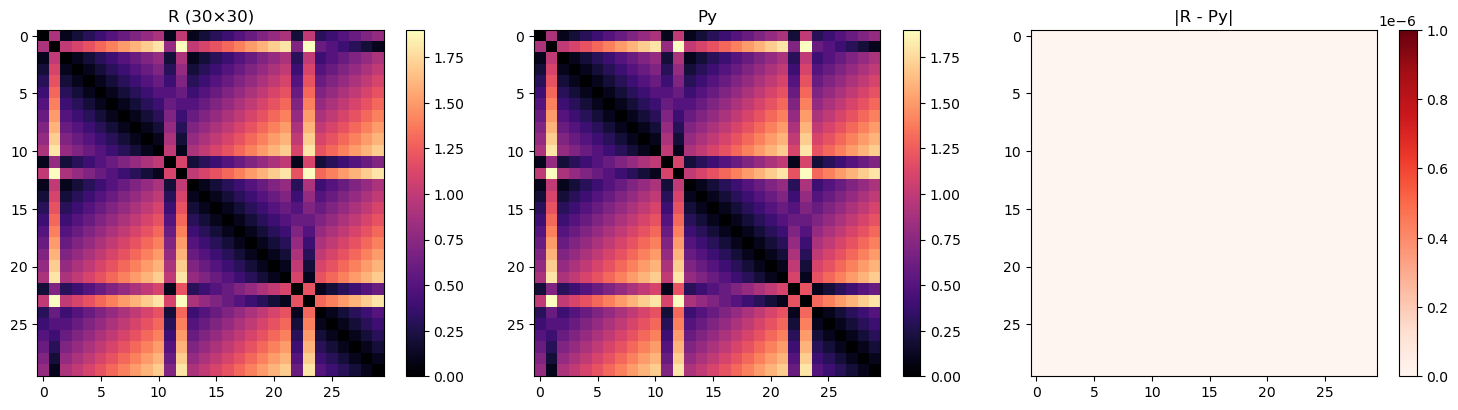

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(A, cmap='magma'); axes[0].set_title(f'R ({A.shape[0]}×{A.shape[1]})')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(B, cmap='magma'); axes[1].set_title(f'Py')
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(np.abs(A-B), cmap='Reds', vmin=0, vmax=1e-6); axes[2].set_title('|R - Py|')
plt.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()